# Análise dos dados de turbidez do HidroAlerta

Este notebook analisa somente os arquivos CSV localizados em `Dados/`. Os experimentos comparam a resposta elétrica de um sensor de turbidez conectado a um ESP32 sob condições relativas de turbidez: água limpa, baixa, média e alta presença de terra peneirada.

Os resultados abaixo devem ser interpretados como evidência experimental relativa. Os dados não estão calibrados em NTU.

## Metodologia resumida

Cada linha dos CSVs resume um ciclo de aquisição do ESP32:

- 50 leituras analógicas do sensor;
- média, mínimo e máximo do ADC;
- tensão média calculada a partir do ADC médio;
- dois testes independentes por condição experimental.

As principais fontes de incerteza são sedimentação, bolhas, mistura não homogênea, ruído do ADC, variação de alimentação, temperatura e pequenas mudanças na posição do sensor.

In [20]:
from pathlib import Path
import csv
import os

# Mantém o cache do Matplotlib dentro do projeto para evitar avisos de permissão no Windows.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = None
    display = print

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# Permite executar o notebook tanto da raiz quanto de Analise_Dos_Dados/.
repo = Path.cwd().resolve()
if repo.name == "Analise_Dos_Dados":
    repo = repo.parent

data_dir = repo / "Dados"

expected_columns = [
    "leitura",
    "tempo_ms",
    "amostra",
    "adc_medio",
    "adc_menor",
    "adc_maior",
    "tensao_media_v",
]

condition_metadata = {
    "agua_limpa": {
        "condicao": "agua_limpa",
        "condicao_ordem": 0,
        "quantidade_terra": "0",
        "descricao": "água limpa",
    },
    "agua_pouca_terra": {
        "condicao": "agua_pouca_terra",
        "condicao_ordem": 1,
        "quantidade_terra": "1/2 colher de chá",
        "descricao": "baixa concentração de partículas",
    },
    "agua_media_terra": {
        "condicao": "agua_media_terra",
        "condicao_ordem": 2,
        "quantidade_terra": "1 colher de chá",
        "descricao": "concentração intermediária de partículas",
    },
    "agua_alta_terra": {
        "condicao": "agua_alta_terra",
        "condicao_ordem": 3,
        "quantidade_terra": "2 colheres de chá",
        "descricao": "alta concentração de partículas",
    },
}

condition_order = [
    "agua_limpa",
    "agua_pouca_terra",
    "agua_media_terra",
    "agua_alta_terra",
]
condition_labels = {
    "agua_limpa": "Água limpa",
    "agua_pouca_terra": "Pouca terra",
    "agua_media_terra": "Média terra",
    "agua_alta_terra": "Alta terra",
}


def parse_csv_line(line):
    """Interpreta linhas CSV normais ou linhas exportadas como um único campo entre aspas."""
    row = next(csv.reader([line]))
    if len(row) == 1 and "," in row[0]:
        row = next(csv.reader([row[0]]))
    return row[: len(expected_columns)]


def read_sensor_csv(path):
    records = []
    with path.open("r", encoding="utf-8-sig", newline="") as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            parsed = parse_csv_line(line)
            if parsed == expected_columns:
                continue
            if len(parsed) != len(expected_columns):
                continue

            record = dict(zip(expected_columns, parsed, strict=True))
            record["leitura"] = int(record["leitura"])
            record["tempo_ms"] = int(record["tempo_ms"])
            record["adc_medio"] = int(record["adc_medio"])
            record["adc_menor"] = int(record["adc_menor"])
            record["adc_maior"] = int(record["adc_maior"])
            record["tensao_media_v"] = float(record["tensao_media_v"])
            record["arquivo"] = path.name
            record["pasta_condicao"] = path.parent.name
            record["teste"] = path.stem
            record["tempo_s"] = record["tempo_ms"] / 1000.0
            record["adc_amplitude"] = record["adc_maior"] - record["adc_menor"]
            record.update(condition_metadata.get(record["amostra"], {}))
            record["condicao"] = record.get("condicao", record["amostra"])
            records.append(record)
    return records


def load_csv_data(csv_paths):
    records = []
    for csv_path in csv_paths:
        records.extend(read_sensor_csv(csv_path))
    if not records:
        raise FileNotFoundError("Nenhum registro legível foi encontrado nos arquivos CSV de Dados/.")
    return pd.DataFrame(records)


def summarize_by_file(data):
    return (
        data.groupby(["condicao_ordem", "condicao", "arquivo"], dropna=False, observed=True)
        .agg(
            linhas=("leitura", "count"),
            tempo_s_min=("tempo_s", "min"),
            tempo_s_max=("tempo_s", "max"),
            adc_medio_media=("adc_medio", "mean"),
            adc_medio_dp=("adc_medio", "std"),
            tensao_media_v_media=("tensao_media_v", "mean"),
            tensao_media_v_dp=("tensao_media_v", "std"),
            adc_amplitude_media=("adc_amplitude", "mean"),
        )
        .reset_index()
        .sort_values(["condicao_ordem", "arquivo"])
    )

csv_files = sorted(data_dir.rglob("*.csv"))
print(f"Arquivos CSV encontrados: {len(csv_files)}")
for path in csv_files:
    print(path.relative_to(repo))

Arquivos CSV encontrados: 8
Dados\1_2_colher_de_cha\agua_pouca_terra_teste_1.csv
Dados\1_2_colher_de_cha\agua_pouca_terra_teste_2.csv
Dados\1_colher_de_cha\agua_media_terra_teste_1.csv
Dados\1_colher_de_cha\agua_media_terra_teste_2.csv
Dados\2_colheres_de_cha\agua_alta_terra_teste_1.csv
Dados\2_colheres_de_cha\agua_alta_terra_teste_2.csv
Dados\agua_limpa\agua_limpa_teste_1.csv
Dados\agua_limpa\agua_limpa_teste_2.csv


In [21]:
df = load_csv_data(csv_files)

# Garante que a análise considere apenas registros vindos dos CSVs encontrados em Dados/.
df = df[df["arquivo"].isin([path.name for path in csv_files])].copy()
df["condicao"] = pd.Categorical(df["condicao"], categories=condition_order, ordered=True)
df["condicao_rotulo"] = df["condicao"].map(condition_labels)
df["numero_teste"] = df["teste"].str.extract(r"teste_(\d+)").astype("Int64")

df.head()

,leitura,tempo_ms,amostra,adc_medio,adc_menor,adc_maior,tensao_media_v,arquivo,pasta_condicao,teste,tempo_s,adc_amplitude,condicao,condicao_ordem,quantidade_terra,descricao,condicao_rotulo,numero_teste
0,1,2523,agua_pouca_terra,779,0,2032,0.6280,agua_pouca_terra_teste_1.csv,1_2_colher_de_cha,agua_pouca_terra_teste_1,2.5230,2032,agua_pouca_terra,1,1/2 colher de chá,baixa concentração de partículas,Pouca terra,1
1,2,5022,agua_pouca_terra,691,0,1861,0.5570,agua_pouca_terra_teste_1.csv,1_2_colher_de_cha,agua_pouca_terra_teste_1,5.0220,1861,agua_pouca_terra,1,1/2 colher de chá,baixa concentração de partículas,Pouca terra,1
2,3,7522,agua_pouca_terra,772,0,1904,0.6220,agua_pouca_terra_teste_1.csv,1_2_colher_de_cha,agua_pouca_terra_teste_1,7.5220,1904,agua_pouca_terra,1,1/2 colher de chá,baixa concentração de partículas,Pouca terra,1
3,4,10022,agua_pouca_terra,758,0,2022,0.6110,agua_pouca_terra_teste_1.csv,1_2_colher_de_cha,agua_pouca_terra_teste_1,10.0220,2022,agua_pouca_terra,1,1/2 colher de chá,baixa concentração de partículas,Pouca terra,1
4,5,12522,agua_pouca_terra,687,0,1959,0.5540,agua_pouca_terra_teste_1.csv,1_2_colher_de_cha,agua_pouca_terra_teste_1,12.5220,1959,agua_pouca_terra,1,1/2 colher de chá,baixa concentração de partículas,Pouca terra,1


## Validação e estrutura dos dados

A etapa abaixo verifica quantidade de linhas por arquivo, colunas esperadas, valores ausentes e a distribuição dos registros por condição experimental.

In [22]:
expected_columns = [
    "leitura",
    "tempo_ms",
    "amostra",
    "adc_medio",
    "adc_menor",
    "adc_maior",
    "tensao_media_v",
]

validation = {
    "linhas": len(df),
    "arquivos_csv": df["arquivo"].nunique(),
    "condicoes": df["condicao"].nunique(),
    "colunas_esperadas_presentes": all(col in df.columns for col in expected_columns),
    "valores_ausentes_total": int(df[expected_columns].isna().sum().sum()),
}

pd.Series(validation, name="valor")

linhas                          994
arquivos_csv                      8
condicoes                         4
colunas_esperadas_presentes    True
valores_ausentes_total            0
Name: valor, dtype: object

In [23]:
linhas_por_arquivo = (
    df.groupby(["condicao", "arquivo"], observed=True)
    .size()
    .rename("linhas")
    .reset_index()
    .sort_values(["condicao", "arquivo"])
)

linhas_por_arquivo

,condicao,arquivo,linhas
0,agua_limpa,agua_limpa_teste_1.csv,127
1,agua_limpa,agua_limpa_teste_2.csv,124
2,agua_pouca_terra,agua_pouca_terra_teste_1.csv,122
3,agua_pouca_terra,agua_pouca_terra_teste_2.csv,123
4,agua_media_terra,agua_media_terra_teste_1.csv,124
5,agua_media_terra,agua_media_terra_teste_2.csv,125
6,agua_alta_terra,agua_alta_terra_teste_1.csv,124
7,agua_alta_terra,agua_alta_terra_teste_2.csv,125


In [24]:
missing_by_column = df[expected_columns].isna().sum().rename("valores_ausentes").to_frame()
missing_by_column

,valores_ausentes
leitura,0
tempo_ms,0
amostra,0
adc_medio,0
adc_menor,0
adc_maior,0
tensao_media_v,0


## Estatísticas descritivas

As estatísticas são calculadas por condição e por arquivo para preservar os testes independentes antes de qualquer agregação.

In [25]:
summary_by_file = summarize_by_file(df)
summary_by_file

,condicao_ordem,condicao,arquivo,linhas,tempo_s_min,tempo_s_max,adc_medio_media,adc_medio_dp,tensao_media_v_media,tensao_media_v_dp,adc_amplitude_media
0,0,agua_limpa,agua_limpa_teste_1.csv,127,2.5230,317.5220,679.4488,33.7911,0.5476,0.0272,1775.0079
1,0,agua_limpa,agua_limpa_teste_2.csv,124,2.5230,310.0230,648.4597,36.5901,0.5226,0.0295,1723.8952
2,1,agua_pouca_terra,agua_pouca_terra_teste_1.csv,122,2.5230,305.0220,701.7213,33.9278,0.5655,0.0274,1844.0738
3,1,agua_pouca_terra,agua_pouca_terra_teste_2.csv,123,2.5230,307.5220,653.0650,31.5126,0.5263,0.0254,1710.8943
4,2,agua_media_terra,agua_media_terra_teste_1.csv,124,2.5230,310.0220,667.9194,30.3003,0.5382,0.0244,1736.5806
5,2,agua_media_terra,agua_media_terra_teste_2.csv,125,2.5230,312.5220,642.1760,29.6153,0.5175,0.0239,1726.0160
6,3,agua_alta_terra,agua_alta_terra_teste_1.csv,124,2.5230,310.0220,655.3548,34.3720,0.5281,0.0277,1741.5484
7,3,agua_alta_terra,agua_alta_terra_teste_2.csv,125,2.5230,312.5220,643.3840,29.8890,0.5185,0.0241,1712.3280


In [26]:
stats_by_condition = (
    df.groupby(["condicao_ordem", "condicao"], observed=True)
    .agg(
        linhas=("leitura", "count"),
        arquivos=("arquivo", "nunique"),
        adc_medio_media=("adc_medio", "mean"),
        adc_medio_dp=("adc_medio", "std"),
        adc_medio_mediana=("adc_medio", "median"),
        tensao_media_v_media=("tensao_media_v", "mean"),
        tensao_media_v_dp=("tensao_media_v", "std"),
        adc_amplitude_media=("adc_amplitude", "mean"),
        adc_amplitude_dp=("adc_amplitude", "std"),
    )
    .reset_index()
    .sort_values("condicao_ordem")
)

stats_by_condition

,condicao_ordem,condicao,linhas,arquivos,adc_medio_media,adc_medio_dp,adc_medio_mediana,tensao_media_v_media,tensao_media_v_dp,adc_amplitude_media,adc_amplitude_dp
0,0,agua_limpa,251,2,664.1394,38.4083,669.0000,0.5352,0.0310,1749.7570,136.3141
1,1,agua_pouca_terra,245,2,677.2939,40.7631,679.0000,0.5458,0.0329,1777.2122,132.5762
2,2,agua_media_terra,249,2,654.9960,32.5612,658.0000,0.5278,0.0262,1731.2771,113.8989
3,3,agua_alta_terra,249,2,649.3454,32.6894,652.0000,0.5233,0.0264,1726.8795,124.4344


## Séries temporais

Os gráficos abaixo mostram a evolução de `adc_medio` e `tensao_media_v` ao longo do tempo para cada condição e teste.

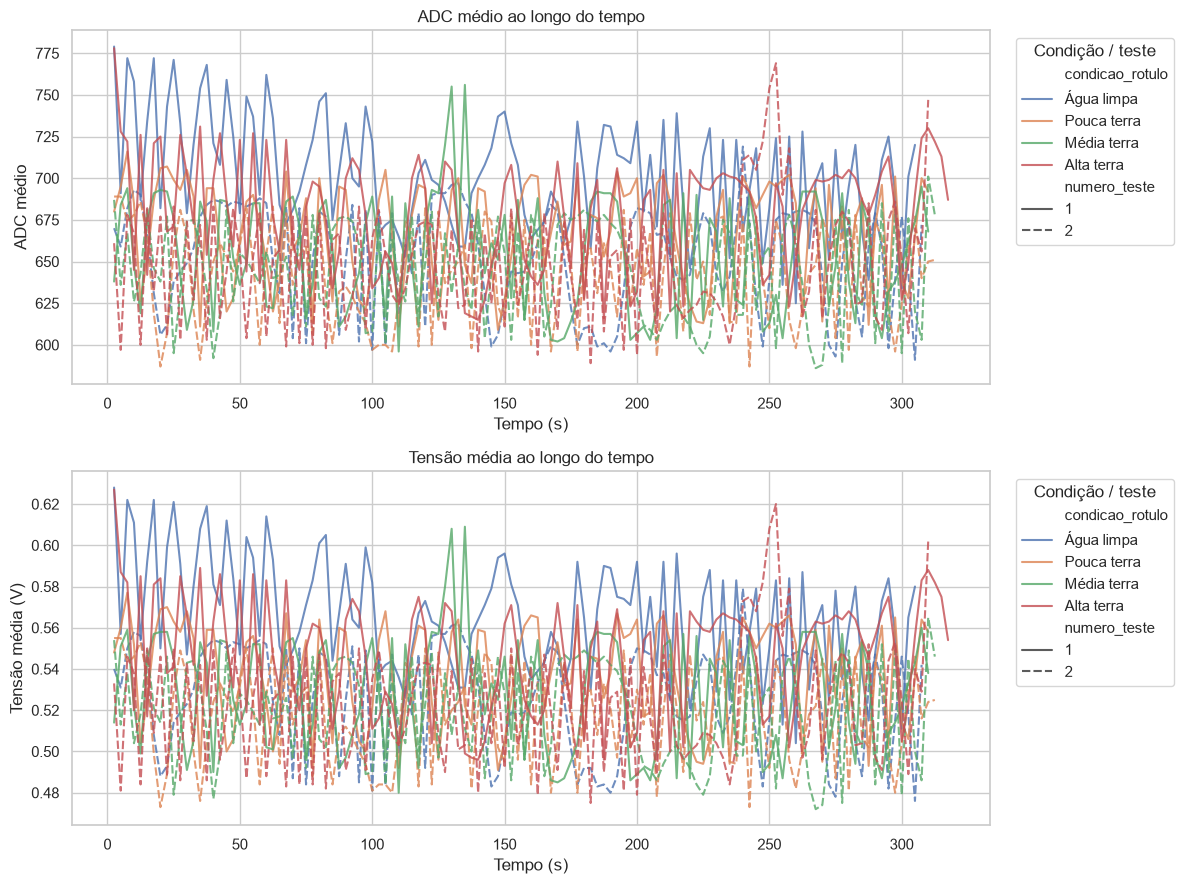

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

sns.lineplot(
    data=df,
    x="tempo_s",
    y="adc_medio",
    hue="condicao_rotulo",
    style="numero_teste",
    estimator=None,
    alpha=0.8,
    ax=axes[0],
)
axes[0].set_title("ADC médio ao longo do tempo")
axes[0].set_xlabel("Tempo (s)")
axes[0].set_ylabel("ADC médio")
axes[0].legend(title="Condição / teste", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.lineplot(
    data=df,
    x="tempo_s",
    y="tensao_media_v",
    hue="condicao_rotulo",
    style="numero_teste",
    estimator=None,
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title("Tensão média ao longo do tempo")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Tensão média (V)")
axes[1].legend(title="Condição / teste", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Comparação das distribuições por condição

Boxplots e violin plots ajudam a observar deslocamento central, dispersão e sobreposição entre as condições experimentais.

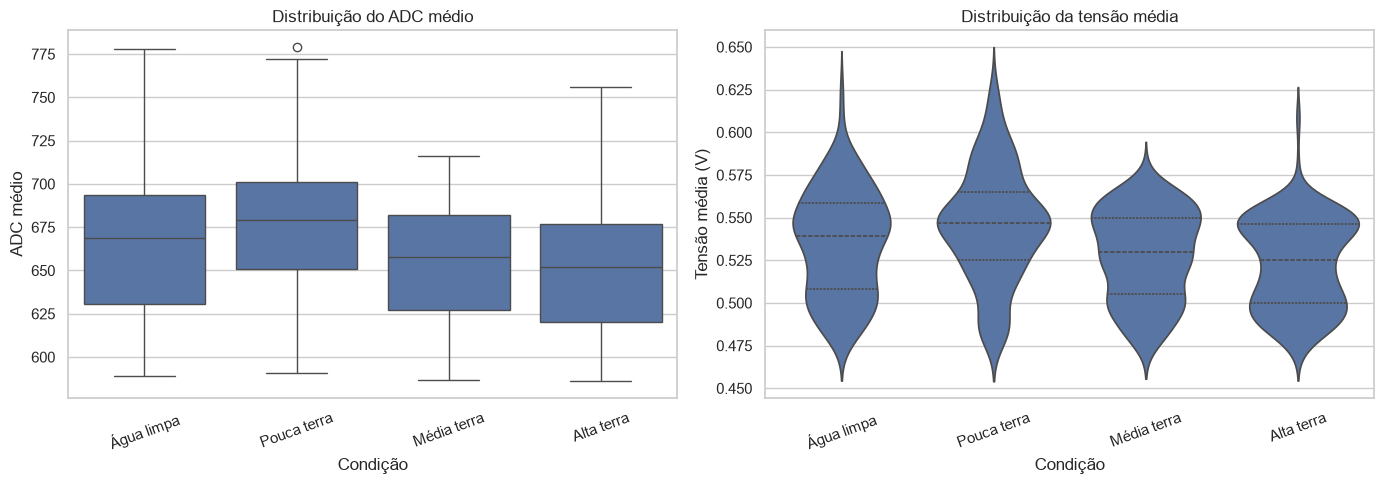

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="condicao_rotulo",
    y="adc_medio",
    order=[condition_labels[c] for c in condition_order],
    ax=axes[0],
)
axes[0].set_title("Distribuição do ADC médio")
axes[0].set_xlabel("Condição")
axes[0].set_ylabel("ADC médio")
axes[0].tick_params(axis="x", rotation=20)

sns.violinplot(
    data=df,
    x="condicao_rotulo",
    y="tensao_media_v",
    order=[condition_labels[c] for c in condition_order],
    inner="quartile",
    ax=axes[1],
)
axes[1].set_title("Distribuição da tensão média")
axes[1].set_xlabel("Condição")
axes[1].set_ylabel("Tensão média (V)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Repetibilidade entre testes

Esta etapa compara os testes independentes 1 e 2 dentro de cada condição. Diferenças grandes sugerem que a variabilidade experimental ainda precisa ser considerada antes de tirar conclusões fortes.

In [29]:
repeatability = (
    df.groupby(["condicao_ordem", "condicao", "numero_teste"], observed=True)
    .agg(
        adc_medio_media=("adc_medio", "mean"),
        tensao_media_v_media=("tensao_media_v", "mean"),
        adc_amplitude_media=("adc_amplitude", "mean"),
        linhas=("leitura", "count"),
    )
    .reset_index()
    .sort_values(["condicao_ordem", "numero_teste"])
)

repeatability

,condicao_ordem,condicao,numero_teste,adc_medio_media,tensao_media_v_media,adc_amplitude_media,linhas
0,0,agua_limpa,1,679.4488,0.5476,1775.0079,127
1,0,agua_limpa,2,648.4597,0.5226,1723.8952,124
2,1,agua_pouca_terra,1,701.7213,0.5655,1844.0738,122
3,1,agua_pouca_terra,2,653.0650,0.5263,1710.8943,123
4,2,agua_media_terra,1,667.9194,0.5382,1736.5806,124
5,2,agua_media_terra,2,642.1760,0.5175,1726.0160,125
6,3,agua_alta_terra,1,655.3548,0.5281,1741.5484,124
7,3,agua_alta_terra,2,643.3840,0.5185,1712.3280,125


In [30]:
repeatability_pivot = repeatability.pivot(
    index=["condicao_ordem", "condicao"],
    columns="numero_teste",
    values=["adc_medio_media", "tensao_media_v_media", "adc_amplitude_media"],
)

repeatability_diff = pd.DataFrame(index=repeatability_pivot.index)
for metric in ["adc_medio_media", "tensao_media_v_media", "adc_amplitude_media"]:
    if (metric, 1) in repeatability_pivot.columns and (metric, 2) in repeatability_pivot.columns:
        repeatability_diff[f"{metric}_dif_t2_t1"] = repeatability_pivot[(metric, 2)] - repeatability_pivot[(metric, 1)]
        repeatability_diff[f"{metric}_dif_percentual"] = (
            repeatability_diff[f"{metric}_dif_t2_t1"] / repeatability_pivot[(metric, 1)] * 100
        )

repeatability_diff.reset_index()

,condicao_ordem,condicao,adc_medio_media_dif_t2_t1,adc_medio_media_dif_percentual,tensao_media_v_media_dif_t2_t1,tensao_media_v_media_dif_percentual,adc_amplitude_media_dif_t2_t1,adc_amplitude_media_dif_percentual
0,0,agua_limpa,-30.9891,-4.5609,-0.0250,-4.5589,-51.1127,-2.8796
1,1,agua_pouca_terra,-48.6563,-6.9338,-0.0392,-6.9386,-133.1795,-7.2220
2,2,agua_media_terra,-25.7434,-3.8543,-0.0207,-3.8442,-10.5646,-0.6084
3,3,agua_alta_terra,-11.9708,-1.8266,-0.0096,-1.8210,-29.2204,-1.6778


C:\Users\mdbaa\AppData\Local\Temp\ipykernel_16500\1654501621.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels([condition_labels[c] for c in condition_order], rotation=20)
C:\Users\mdbaa\AppData\Local\Temp\ipykernel_16500\1654501621.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels([condition_labels[c] for c in condition_order], rotation=20)


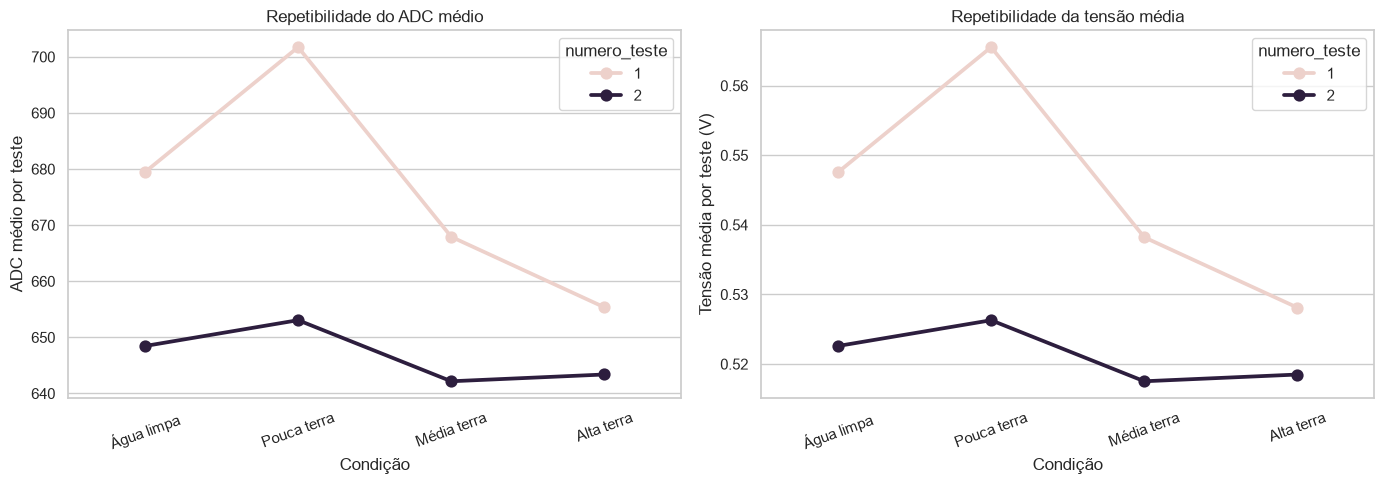

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.pointplot(
    data=repeatability,
    x="condicao",
    y="adc_medio_media",
    hue="numero_teste",
    order=condition_order,
    ax=axes[0],
)
axes[0].set_title("Repetibilidade do ADC médio")
axes[0].set_xlabel("Condição")
axes[0].set_ylabel("ADC médio por teste")
axes[0].set_xticklabels([condition_labels[c] for c in condition_order], rotation=20)

sns.pointplot(
    data=repeatability,
    x="condicao",
    y="tensao_media_v_media",
    hue="numero_teste",
    order=condition_order,
    ax=axes[1],
)
axes[1].set_title("Repetibilidade da tensão média")
axes[1].set_xlabel("Condição")
axes[1].set_ylabel("Tensão média por teste (V)")
axes[1].set_xticklabels([condition_labels[c] for c in condition_order], rotation=20)

plt.tight_layout()
plt.show()

## Dispersão dentro dos ciclos de aquisição

A variável `adc_amplitude = adc_maior - adc_menor` resume a variação interna em cada ciclo de 50 leituras. Ela pode indicar instabilidade de curto prazo, bolhas, movimentação da água ou ruído elétrico.

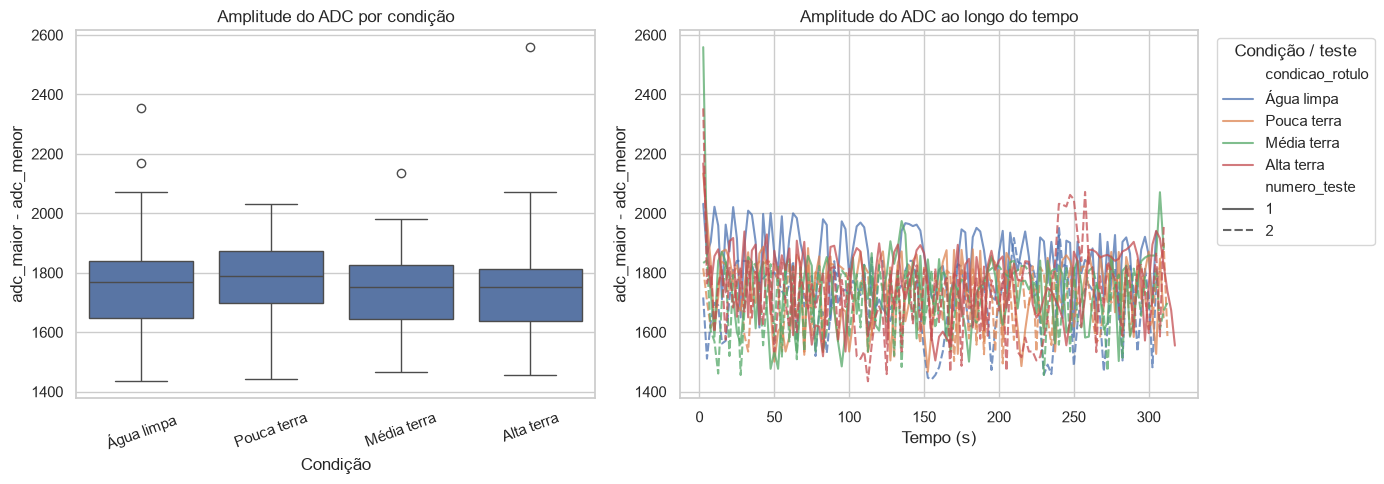

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="condicao_rotulo",
    y="adc_amplitude",
    order=[condition_labels[c] for c in condition_order],
    ax=axes[0],
)
axes[0].set_title("Amplitude do ADC por condição")
axes[0].set_xlabel("Condição")
axes[0].set_ylabel("adc_maior - adc_menor")
axes[0].tick_params(axis="x", rotation=20)

sns.lineplot(
    data=df,
    x="tempo_s",
    y="adc_amplitude",
    hue="condicao_rotulo",
    style="numero_teste",
    estimator=None,
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title("Amplitude do ADC ao longo do tempo")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("adc_maior - adc_menor")
axes[1].legend(title="Condição / teste", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Tendência contra a turbidez relativa ordenada

A condição experimental é ordinal: água limpa < pouca terra < média terra < alta terra. A análise abaixo compara essa ordem com as respostas elétricas médias do sensor.

In [33]:
trend_table = stats_by_condition[[
    "condicao_ordem",
    "condicao",
    "adc_medio_media",
    "tensao_media_v_media",
    "adc_amplitude_media",
]].copy()

try:
    from scipy.stats import spearmanr

    trend_results = []
    for metric in ["adc_medio", "tensao_media_v", "adc_amplitude"]:
        rho, p_value = spearmanr(df["condicao_ordem"], df[metric])
        trend_results.append({
            "metrica": metric,
            "spearman_rho": rho,
            "p_valor": p_value,
        })
    trend_results = pd.DataFrame(trend_results)
except ImportError:
    trend_results = pd.DataFrame({
        "observacao": ["scipy não está instalado; instale scipy para calcular Spearman."]
    })

trend_table, trend_results

(   condicao_ordem          condicao  adc_medio_media  tensao_media_v_media  \
 0               0        agua_limpa         664.1394                0.5352   
 1               1  agua_pouca_terra         677.2939                0.5458   
 2               2  agua_media_terra         654.9960                0.5278   
 3               3   agua_alta_terra         649.3454                0.5233   
 
    adc_amplitude_media  
 0            1749.7570  
 1            1777.2122  
 2            1731.2771  
 3            1726.8795  ,
           metrica  spearman_rho  p_valor
 0       adc_medio       -0.1899   0.0000
 1  tensao_media_v       -0.1902   0.0000
 2   adc_amplitude       -0.1069   0.0007)

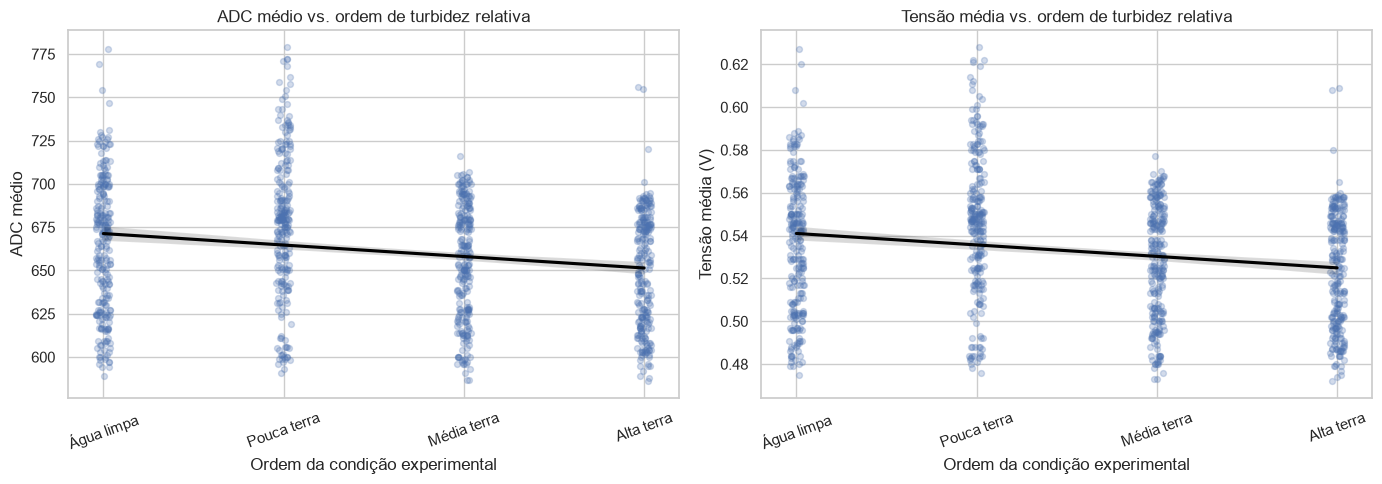

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=df,
    x="condicao_ordem",
    y="adc_medio",
    x_jitter=0.04,
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "black"},
    ax=axes[0],
)
axes[0].set_title("ADC médio vs. ordem de turbidez relativa")
axes[0].set_xlabel("Ordem da condição experimental")
axes[0].set_ylabel("ADC médio")
axes[0].set_xticks(range(len(condition_order)))
axes[0].set_xticklabels([condition_labels[c] for c in condition_order], rotation=20)

sns.regplot(
    data=df,
    x="condicao_ordem",
    y="tensao_media_v",
    x_jitter=0.04,
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "black"},
    ax=axes[1],
)
axes[1].set_title("Tensão média vs. ordem de turbidez relativa")
axes[1].set_xlabel("Ordem da condição experimental")
axes[1].set_ylabel("Tensão média (V)")
axes[1].set_xticks(range(len(condition_order)))
axes[1].set_xticklabels([condition_labels[c] for c in condition_order], rotation=20)

plt.tight_layout()
plt.show()

## Classificação visual da turbidez relativa

Para facilitar a leitura final, o gráfico abaixo transforma a condição experimental conhecida em uma escala qualitativa simples:

- **Limpa**: água de controle, sem adição de terra;
- **Pouca turbidez**: 1/2 colher de chá de terra;
- **Turbidez média**: 1 colher de chá de terra;
- **Alta turbidez / suja**: 2 colheres de chá de terra.

Essa classificação não indica potabilidade. Ela apenas resume o nível relativo de partículas usado no experimento.

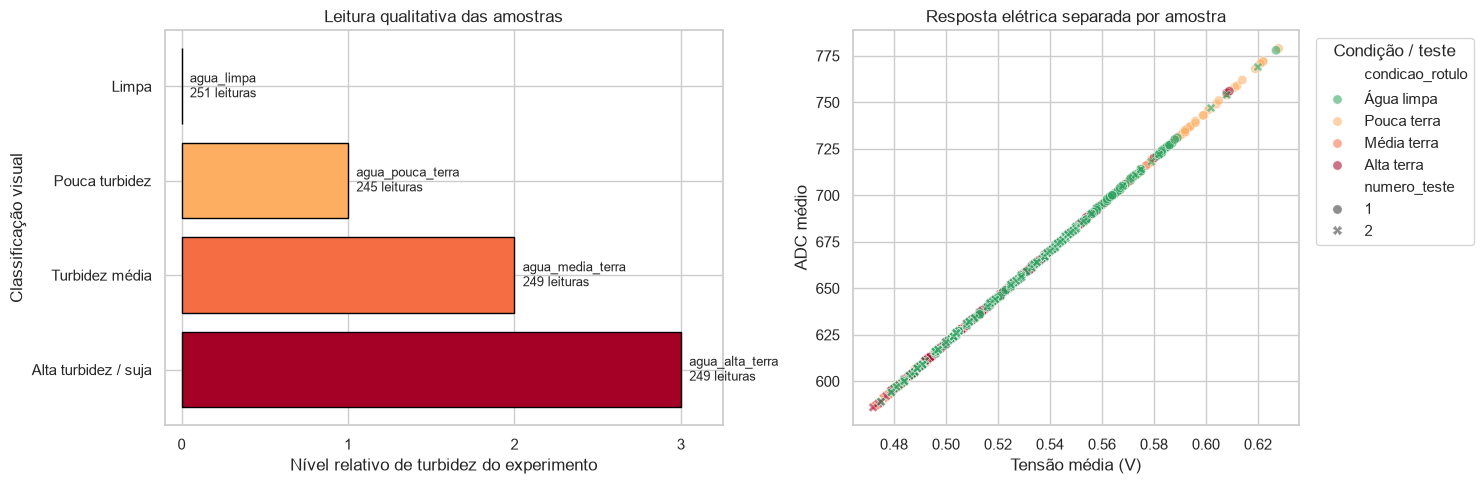

,classe_visual,condicao,leituras,adc_medio_media,tensao_media_v_media,adc_amplitude_media
0,Limpa,agua_limpa,251,664.1394,0.5352,1749.7570
1,Pouca turbidez,agua_pouca_terra,245,677.2939,0.5458,1777.2122
2,Turbidez média,agua_media_terra,249,654.9960,0.5278,1731.2771
3,Alta turbidez / suja,agua_alta_terra,249,649.3454,0.5233,1726.8795


In [35]:
classification_labels = {
    "agua_limpa": "Limpa",
    "agua_pouca_terra": "Pouca turbidez",
    "agua_media_terra": "Turbidez média",
    "agua_alta_terra": "Alta turbidez / suja",
}
classification_colors = {
    "Limpa": "#2ca25f",
    "Pouca turbidez": "#fdae61",
    "Turbidez média": "#f46d43",
    "Alta turbidez / suja": "#a50026",
}

classification_summary = (
    df.groupby(["condicao_ordem", "condicao"], observed=True)
    .agg(
        adc_medio_media=("adc_medio", "mean"),
        adc_medio_dp=("adc_medio", "std"),
        tensao_media_v_media=("tensao_media_v", "mean"),
        adc_amplitude_media=("adc_amplitude", "mean"),
        leituras=("leitura", "count"),
    )
    .reset_index()
    .sort_values("condicao_ordem")
)
classification_summary["classe_visual"] = classification_summary["condicao"].map(classification_labels)
classification_summary["cor"] = classification_summary["classe_visual"].map(classification_colors)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.25, 1]})

axes[0].barh(
    classification_summary["classe_visual"],
    classification_summary["condicao_ordem"],
    color=classification_summary["cor"],
    edgecolor="black",
)
axes[0].set_xlim(-0.1, 3.25)
axes[0].set_xticks([0, 1, 2, 3])
axes[0].set_xlabel("Nível relativo de turbidez do experimento")
axes[0].set_ylabel("Classificação visual")
axes[0].set_title("Leitura qualitativa das amostras")
axes[0].invert_yaxis()

for _, row in classification_summary.iterrows():
    axes[0].text(
        row["condicao_ordem"] + 0.05,
        row["classe_visual"],
        f"{row['condicao']}\n{row['leituras']} leituras",
        va="center",
        fontsize=9,
    )

sns.scatterplot(
    data=df,
    x="tensao_media_v",
    y="adc_medio",
    hue="condicao_rotulo",
    style="numero_teste",
    palette=[classification_colors[classification_labels[c]] for c in condition_order],
    alpha=0.55,
    s=45,
    ax=axes[1],
)
axes[1].set_title("Resposta elétrica separada por amostra")
axes[1].set_xlabel("Tensão média (V)")
axes[1].set_ylabel("ADC médio")
axes[1].legend(title="Condição / teste", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

classification_summary[[
    "classe_visual",
    "condicao",
    "leituras",
    "adc_medio_media",
    "tensao_media_v_media",
    "adc_amplitude_media",
]]

In [36]:
final_reading = """
### Leitura final em linguagem simples

- A amostra `agua_limpa` representa a água limpa de referência do experimento.
- A amostra `agua_pouca_terra` representa uma água com pouca turbidez relativa.
- A amostra `agua_media_terra` representa uma água com turbidez intermediária.
- A amostra `agua_alta_terra` representa a condição mais suja/mais turva do experimento.

Importante: essa leitura usa a preparação experimental das amostras e a resposta elétrica do sensor. Ela não deve ser usada para dizer se a água é potável, nem para informar valores em NTU sem calibração.
"""

if Markdown is not None:
    display(Markdown(final_reading))
else:
    print(final_reading)


### Leitura final em linguagem simples

- A amostra `agua_limpa` representa a água limpa de referência do experimento.
- A amostra `agua_pouca_terra` representa uma água com pouca turbidez relativa.
- A amostra `agua_media_terra` representa uma água com turbidez intermediária.
- A amostra `agua_alta_terra` representa a condição mais suja/mais turva do experimento.

Importante: essa leitura usa a preparação experimental das amostras e a resposta elétrica do sensor. Ela não deve ser usada para dizer se a água é potável, nem para informar valores em NTU sem calibração.


## Síntese interpretativa

Execute a célula abaixo depois das análises para gerar um resumo textual baseado nas estatísticas calculadas. A linguagem evita afirmações de calibração em NTU e trata os resultados como comparação relativa do sensor.

In [37]:
control_adc = stats_by_condition.loc[stats_by_condition["condicao"] == "agua_limpa", "adc_medio_media"].iloc[0]
control_voltage = stats_by_condition.loc[stats_by_condition["condicao"] == "agua_limpa", "tensao_media_v_media"].iloc[0]

max_adc_row = stats_by_condition.loc[stats_by_condition["adc_medio_media"].idxmax()]
min_adc_row = stats_by_condition.loc[stats_by_condition["adc_medio_media"].idxmin()]
max_dispersion_row = stats_by_condition.loc[stats_by_condition["adc_amplitude_media"].idxmax()]

summary_text = f"""
### Conclusões preliminares

- Foram analisadas {len(df)} leituras provenientes de {df['arquivo'].nunique()} arquivos CSV em `Dados/`.
- A condição de controle (`agua_limpa`) apresentou ADC médio de {control_adc:.2f} e tensão média de {control_voltage:.4f} V.
- A maior média de ADC ocorreu em `{max_adc_row['condicao']}` ({max_adc_row['adc_medio_media']:.2f}).
- A menor média de ADC ocorreu em `{min_adc_row['condicao']}` ({min_adc_row['adc_medio_media']:.2f}).
- A maior dispersão média dentro dos ciclos de aquisição ocorreu em `{max_dispersion_row['condicao']}` (`adc_amplitude` médio = {max_dispersion_row['adc_amplitude_media']:.2f}).
- As diferenças entre testes independentes devem ser consideradas antes de afirmar uma tendência robusta entre concentração relativa de partículas e resposta elétrica.
- Estes dados sugerem diferenças relativas na resposta do sensor, mas não permitem estimar NTU sem calibração com padrões certificados ou turbidímetro de referência.
"""

if Markdown is not None:
    display(Markdown(summary_text))
else:
    print(summary_text)


### Conclusões preliminares

- Foram analisadas 994 leituras provenientes de 8 arquivos CSV em `Dados/`.
- A condição de controle (`agua_limpa`) apresentou ADC médio de 664.14 e tensão média de 0.5352 V.
- A maior média de ADC ocorreu em `agua_pouca_terra` (677.29).
- A menor média de ADC ocorreu em `agua_alta_terra` (649.35).
- A maior dispersão média dentro dos ciclos de aquisição ocorreu em `agua_pouca_terra` (`adc_amplitude` médio = 1777.21).
- As diferenças entre testes independentes devem ser consideradas antes de afirmar uma tendência robusta entre concentração relativa de partículas e resposta elétrica.
- Estes dados sugerem diferenças relativas na resposta do sensor, mas não permitem estimar NTU sem calibração com padrões certificados ou turbidímetro de referência.


## Próximos passos recomendados

- Repetir os experimentos com melhor controle de mistura e sedimentação.
- Registrar temperatura, tempo de repouso e posição do sensor.
- Usar padrões de turbidez conhecidos para construir uma curva de calibração.
- Comparar as leituras com um turbidímetro de referência antes de qualquer estimativa em NTU.
- Separar claramente análise exploratória, calibração e validação do modelo em notebooks diferentes quando o volume de dados crescer.